# Netflix Content Data Engineering Pipeline

## 1. Project Overview

This project builds a data engineering pipeline for the Netflix titles dataset using PySpark and Databricks.

The pipeline follows a Bronze–Silver–Gold architecture:

- **Bronze:** Raw source data
- **Silver:** Cleaned and transformed dataset
- **Gold:** Analytical datasets designed for business analysis

The project includes data quality validation, transformations, analytical modeling, Delta Lake persistence, and visualizations.

## 2. Environment Setup

The project uses PySpark for data ingestion, transformation, validation, and analytical processing. Matplotlib is used for visualizing aggregated results.

In [0]:
from pyspark.sql import functions
from pyspark.sql.functions import (
    col,
    count,
    countDistinct,
    explode,
    split,
    trim,
    to_date,
    year,
    when,
    avg,
    min,
    max,
    round,
    sum as spark_sum
)

import matplotlib.pyplot as plt

## 3. Bronze Layer — Data Ingestion

### 3.1 Load Raw Dataset

In [0]:
df= spark.read.option("quote",'"').option("escape", "\"").option("multiline", "true").option("header", "true").option("inferSchema", "true").csv("/Volumes/workspace/default/netflix_vol/raw/netflix_titles.csv")

### 3.2 Initial Data Inspection

Inspect the raw dataset to understand its structure, data types, and sample records before applying any transformations.

In [0]:
df.show(5)
df.printSchema()

+-------+-------+--------------------+---------------+--------------------+-------------+------------------+------------+------+---------+--------------------+--------------------+
|show_id|   type|               title|       director|                cast|      country|        date_added|release_year|rating| duration|           listed_in|         description|
+-------+-------+--------------------+---------------+--------------------+-------------+------------------+------------+------+---------+--------------------+--------------------+
|     s1|  Movie|Dick Johnson Is Dead|Kirsten Johnson|                NULL|United States|September 25, 2021|        2020| PG-13|   90 min|       Documentaries|As her father nea...|
|     s2|TV Show|       Blood & Water|           NULL|Ama Qamata, Khosi...| South Africa|September 24, 2021|        2021| TV-MA|2 Seasons|International TV ...|After crossing pa...|
|     s3|TV Show|           Ganglands|Julien Leclercq|Sami Bouajila, Tr...|         NULL|Septem

## 4. Silver Layer — Data Cleaning & Transformation

In [0]:
#checking for nulls
print("total num of rows", df.count())
df.select([spark_sum(col(c).isNull().cast("int")).alias(c) for c in df.columns]).show()
#checking for duplicates in the primary key column(show_id)
dup_check = ["show_id"]
print("duplicate rows:", df.count()- df.dropDuplicates(dup_check).count())

total num of rows 8807
+-------+----+-----+--------+----+-------+----------+------------+------+--------+---------+-----------+
|show_id|type|title|director|cast|country|date_added|release_year|rating|duration|listed_in|description|
+-------+----+-----+--------+----+-------+----------+------------+------+--------+---------+-----------+
|      0|   0|    0|    2634| 825|    831|        10|           0|     4|       3|        0|          0|
+-------+----+-----+--------+----+-------+----------+------------+------+--------+---------+-----------+

duplicate rows: 0


### 4.1 Data Quality Assessment

The raw dataset was checked for missing values and duplicate `show_id` values. Missing values in key fields were then investigated before applying appropriate cleaning rules.

In [0]:
df.filter(df.title.isNull()).show()

+-------+----+-----+--------+----+-------+----------+------------+------+--------+---------+-----------+
|show_id|type|title|director|cast|country|date_added|release_year|rating|duration|listed_in|description|
+-------+----+-----+--------+----+-------+----------+------------+------+--------+---------+-----------+
+-------+----+-----+--------+----+-------+----------+------------+------+--------+---------+-----------+



### 4.2 Handling Missing Values

Missing values in `cast`, `country`, `director`, and `rating` are represented as `Unknown` rather than being removed, since these missing attributes do not invalidate the underlying title.

The dataset contains a small number of missing `date_added` values, which are retained because they do not prevent the remaining title-level information from being used for analysis.

In [0]:
df.filter(col("rating").isNull()).show()

+-------+-------+--------------------+---------------+--------------------+---------+----------------+------------+------+--------+--------------------+--------------------+
|show_id|   type|               title|       director|                cast|  country|      date_added|release_year|rating|duration|           listed_in|         description|
+-------+-------+--------------------+---------------+--------------------+---------+----------------+------------+------+--------+--------------------+--------------------+
|  s5990|  Movie|13TH: A Conversat...|           NULL|Oprah Winfrey, Av...|     NULL|January 26, 2017|        2017|  NULL|  37 min|              Movies|Oprah Winfrey sit...|
|  s6828|TV Show|Gargantia on the ...|           NULL|Kaito Ishikawa, H...|    Japan|December 1, 2016|        2013|  NULL|1 Season|Anime Series, Int...|After falling thr...|
|  s7313|TV Show|        Little Lunch|           NULL|Flynn Curry, Oliv...|Australia|February 1, 2018|        2015|  NULL|1 Season

In [0]:
df = df.fillna("Unknown", ["cast", "country", "director", "rating"])

### 4.3 Date Transformation

The `date_added` column is converted from string to date format to support time-based analysis. The year is then extracted into a separate `added_year` column for analytical use.

In [0]:
df = df.withColumn(
    "date_added",
    to_date(trim(df.date_added), "MMMM d, yyyy")
)

In [0]:
df = df.withColumn(
    "added_year",
    year(col("date_added"))
)

In [0]:
df.select(
    "date_added",
    "added_year",
    "release_year"
).show(20, truncate=False)

+----------+----------+------------+
|date_added|added_year|release_year|
+----------+----------+------------+
|2021-09-25|2021      |2020        |
|2021-09-24|2021      |2021        |
|2021-09-24|2021      |2021        |
|2021-09-24|2021      |2021        |
|2021-09-24|2021      |2021        |
|2021-09-24|2021      |2021        |
|2021-09-24|2021      |2021        |
|2021-09-24|2021      |1993        |
|2021-09-24|2021      |2021        |
|2021-09-24|2021      |2021        |
|2021-09-24|2021      |2021        |
|2021-09-23|2021      |2021        |
|2021-09-23|2021      |2021        |
|2021-09-22|2021      |2021        |
|2021-09-22|2021      |2021        |
|2021-09-22|2021      |2021        |
|2021-09-22|2021      |2020        |
|2021-09-22|2021      |2020        |
|2021-09-22|2021      |2021        |
|2021-09-22|2021      |2021        |
+----------+----------+------------+
only showing top 20 rows


### 4.4 Duration Transformation

The `duration` column is inspected for missing values and potential data-quality issues. Three records contain duration values incorrectly placed in the `rating` column. These values are recovered, the affected ratings are set to `Unknown`, and `duration` is split into numeric value and unit columns.

In [0]:
df.filter(df.duration.isNull()).show()

+-------+-----+--------------------+----------+----------+-------------+----------+------------+------+--------+---------+--------------------+----------+
|show_id| type|               title|  director|      cast|      country|date_added|release_year|rating|duration|listed_in|         description|added_year|
+-------+-----+--------------------+----------+----------+-------------+----------+------------+------+--------+---------+--------------------+----------+
|  s5542|Movie|     Louis C.K. 2017|Louis C.K.|Louis C.K.|United States|2017-04-04|        2017|74 min|    NULL|   Movies|Louis C.K. muses ...|      2017|
|  s5795|Movie|Louis C.K.: Hilar...|Louis C.K.|Louis C.K.|United States|2016-09-16|        2010|84 min|    NULL|   Movies|Emmy-winning come...|      2016|
|  s5814|Movie|Louis C.K.: Live ...|Louis C.K.|Louis C.K.|United States|2016-08-15|        2015|66 min|    NULL|   Movies|The comic puts hi...|      2016|
+-------+-----+--------------------+----------+----------+------------

In [0]:
df.filter(
    col("rating").contains("min") |
    col("rating").contains("seasons") |
    col("rating").contains("season")
).select(
    "show_id",
    "rating",
    "duration"
).show()

+-------+------+--------+
|show_id|rating|duration|
+-------+------+--------+
|  s5542|74 min|    NULL|
|  s5795|84 min|    NULL|
|  s5814|66 min|    NULL|
+-------+------+--------+



In [0]:
#recover the duration
df= df.withColumn("duration",
                  when(col("duration").isNull() & 
                  col("rating").contains("min"),
                  col("rating")).otherwise(col("duration"))
)

In [0]:
df.filter(
    col("show_id").isin("s5542", "s5795", "s5814")
).select(
    "show_id",
    "rating",
    "duration"
).show()

+-------+------+--------+
|show_id|rating|duration|
+-------+------+--------+
|  s5542|74 min|  74 min|
|  s5795|84 min|  84 min|
|  s5814|66 min|  66 min|
+-------+------+--------+



Three records contain values such as `74 min`, `84 min`, and `66 min` in the `rating` column while `duration` is null. These values are treated as misplaced duration values.

In [0]:
df=df.withColumn("rating",
                 when(col("rating").contains("min"), "Unknown").otherwise(col("rating")))

In [0]:
df_split=split(col("duration"), " ")
df= df.withColumn("duration_value", df_split[0].cast("int"))
df= df.withColumn("duration_unit", df_split[1])
df.select("duration", "duration_value", "duration_unit").show()

+---------+--------------+-------------+
| duration|duration_value|duration_unit|
+---------+--------------+-------------+
|   90 min|            90|          min|
|2 Seasons|             2|      Seasons|
| 1 Season|             1|       Season|
| 1 Season|             1|       Season|
|2 Seasons|             2|      Seasons|
| 1 Season|             1|       Season|
|   91 min|            91|          min|
|  125 min|           125|          min|
|9 Seasons|             9|      Seasons|
|  104 min|           104|          min|
| 1 Season|             1|       Season|
| 1 Season|             1|       Season|
|  127 min|           127|          min|
|   91 min|            91|          min|
| 1 Season|             1|       Season|
|4 Seasons|             4|      Seasons|
|   67 min|            67|          min|
|2 Seasons|             2|      Seasons|
|   94 min|            94|          min|
| 1 Season|             1|       Season|
+---------+--------------+-------------+
only showing top

In [0]:
df = df.withColumn(
    "duration_unit",
    when(col("duration_unit") == "Season", "Seasons")
    .otherwise(col("duration_unit"))
)

In [0]:
df.filter(df.duration.isNull())\
    .select("show_id","title", "duration", "duration_unit", "duration_value").show()

+-------+-----+--------+-------------+--------------+
|show_id|title|duration|duration_unit|duration_value|
+-------+-----+--------+-------------+--------------+
+-------+-----+--------+-------------+--------------+



In [0]:
# Checking type and duration_unit compatibility

df.filter(
    (col("type") == "Movie") &
    (col("duration_unit") != "min")
).show()

df.filter(
    (col("type") == "TV Show") &
    (col("duration_unit") != "Seasons")
).show()

+-------+----+-----+--------+----+-------+----------+------------+------+--------+---------+-----------+----------+--------------+-------------+
|show_id|type|title|director|cast|country|date_added|release_year|rating|duration|listed_in|description|added_year|duration_value|duration_unit|
+-------+----+-----+--------+----+-------+----------+------------+------+--------+---------+-----------+----------+--------------+-------------+
+-------+----+-----+--------+----+-------+----------+------------+------+--------+---------+-----------+----------+--------------+-------------+

+-------+----+-----+--------+----+-------+----------+------------+------+--------+---------+-----------+----------+--------------+-------------+
|show_id|type|title|director|cast|country|date_added|release_year|rating|duration|listed_in|description|added_year|duration_value|duration_unit|
+-------+----+-----+--------+----+-------+----------+------------+------+--------+---------+-----------+----------+--------------

In [0]:
# Checking release year and added year consistency

df.filter((col("added_year").isNotNull()) & (col("release_year") > col("added_year"))).select("show_id", "release_year", "added_year").show()

+-------+------------+----------+
|show_id|release_year|added_year|
+-------+------------+----------+
|  s1552|        2021|      2020|
|  s1697|        2021|      2020|
|  s2921|        2021|      2020|
|  s3169|        2020|      2019|
|  s3288|        2020|      2019|
|  s3370|        2020|      2019|
|  s3434|        2020|      2019|
|  s4845|        2019|      2018|
|  s4846|        2019|      2018|
|  s5395|        2018|      2017|
|  s5659|        2018|      2016|
|  s5678|        2017|      2016|
|  s7064|        2019|      2018|
|  s7113|        2016|      2013|
+-------+------------+----------+



**Data Quality Observation:**  
Some records have a `release_year` later than their `added_year`. These records are retained because the two fields represent different business concepts: `release_year` indicates when the content was released, while `added_year` indicates when it was added to Netflix. Therefore, this condition does not necessarily indicate invalid data.

### 4.5 Silver Layer Validation

The cleaned Silver dataset is validated to confirm that the required transformations were applied successfully and that no unexpected nulls or duplicate records remain.

In [0]:
print("Number of rows:", df.count())
print("duplicate show_ids: ",
      df.count()- df.dropDuplicates(["show_id"]).count()
    )
df.printSchema()

Number of rows: 8807
duplicate show_ids:  0
root
 |-- show_id: string (nullable = true)
 |-- type: string (nullable = true)
 |-- title: string (nullable = true)
 |-- director: string (nullable = false)
 |-- cast: string (nullable = false)
 |-- country: string (nullable = false)
 |-- date_added: date (nullable = true)
 |-- release_year: integer (nullable = true)
 |-- rating: string (nullable = false)
 |-- duration: string (nullable = true)
 |-- listed_in: string (nullable = true)
 |-- description: string (nullable = true)
 |-- added_year: integer (nullable = true)
 |-- duration_value: integer (nullable = true)
 |-- duration_unit: string (nullable = true)



In [0]:
df.select(
    "show_id",
    "title",
    "date_added",
    "added_year",
    "duration",
    "duration_value",
    "duration_unit"
).show(10, truncate=False)

+-------+--------------------------------+----------+----------+---------+--------------+-------------+
|show_id|title                           |date_added|added_year|duration |duration_value|duration_unit|
+-------+--------------------------------+----------+----------+---------+--------------+-------------+
|s1     |Dick Johnson Is Dead            |2021-09-25|2021      |90 min   |90            |min          |
|s2     |Blood & Water                   |2021-09-24|2021      |2 Seasons|2             |Seasons      |
|s3     |Ganglands                       |2021-09-24|2021      |1 Season |1             |Seasons      |
|s4     |Jailbirds New Orleans           |2021-09-24|2021      |1 Season |1             |Seasons      |
|s5     |Kota Factory                    |2021-09-24|2021      |2 Seasons|2             |Seasons      |
|s6     |Midnight Mass                   |2021-09-24|2021      |1 Season |1             |Seasons      |
|s7     |My Little Pony: A New Generation|2021-09-24|2021      |

In [0]:
df.select([
    spark_sum(col(c).isNull().cast("int")).alias(c)
    for c in df.columns
]).show()

+-------+----+-----+--------+----+-------+----------+------------+------+--------+---------+-----------+----------+--------------+-------------+
|show_id|type|title|director|cast|country|date_added|release_year|rating|duration|listed_in|description|added_year|duration_value|duration_unit|
+-------+----+-----+--------+----+-------+----------+------------+------+--------+---------+-----------+----------+--------------+-------------+
|      0|   0|    0|       0|   0|      0|        10|           0|     0|       0|        0|          0|        10|             0|            0|
+-------+----+-----+--------+----+-------+----------+------------+------+--------+---------+-----------+----------+--------------+-------------+



### 4.6 Persist Silver Layer

The cleaned and validated dataset is persisted as a Delta table in the Silver layer for downstream analytical processing.

In [0]:
df.write\
    .format("delta")\
        .mode("overwrite")\
            .option("overwriteSchema", "true")\
            .save("/Volumes/workspace/default/netflix_vol/silver/silver_dataset")

In [0]:
#reading the silver dataset back to verify

silver_df = spark.read\
    .format("delta")\
    .load("/Volumes/workspace/default/netflix_vol/silver/silver_dataset")

In [0]:
print("Silver row count:", silver_df.count())
silver_df.printSchema()
silver_df.show(5)

Silver row count: 8807
root
 |-- show_id: string (nullable = true)
 |-- type: string (nullable = true)
 |-- title: string (nullable = true)
 |-- director: string (nullable = true)
 |-- cast: string (nullable = true)
 |-- country: string (nullable = true)
 |-- date_added: date (nullable = true)
 |-- release_year: integer (nullable = true)
 |-- rating: string (nullable = true)
 |-- duration: string (nullable = true)
 |-- listed_in: string (nullable = true)
 |-- description: string (nullable = true)
 |-- added_year: integer (nullable = true)
 |-- duration_value: integer (nullable = true)
 |-- duration_unit: string (nullable = true)

+-------+-------+--------------------+---------------+--------------------+-------------+----------+------------+------+---------+--------------------+--------------------+----------+--------------+-------------+
|show_id|   type|               title|       director|                cast|      country|date_added|release_year|rating| duration|           listed_i

## 5. Gold Layer — Analytical Data Modeling

The Gold layer contains purpose-built analytical datasets derived from the validated Silver layer. Each dataset is designed to support a specific business analysis while keeping the model focused on useful aggregated information.

### 5.1 Content Overview

The Silver dataset is analyzed at a high level to understand the distribution of Movies and TV Shows before creating the detailed Gold datasets.

In [0]:
silver_df.groupBy("type").count().show()

+-------+-----+
|   type|count|
+-------+-----+
|  Movie| 6131|
|TV Show| 2676|
+-------+-----+



### 5.2 Gold Country

The `country` column can contain multiple countries for a single title. The values are split and exploded so that each country can be analyzed separately. Duplicate country entries within the same title are handled using `countDistinct("show_id")`.

In [0]:
# Inspect the country column
silver_df.select("country").show()

+--------------------+
|             country|
+--------------------+
|       United States|
|        South Africa|
|             Unknown|
|             Unknown|
|               India|
|             Unknown|
|             Unknown|
|United States, Gh...|
|      United Kingdom|
|       United States|
|             Unknown|
|             Unknown|
|Germany, Czech Re...|
|             Unknown|
|             Unknown|
|       United States|
|             Unknown|
|              Mexico|
|             Unknown|
|             Unknown|
+--------------------+
only showing top 20 rows


In [0]:
# Split the comma-separated country values
country_split = split(col("country"), ",")

In [0]:
country_df = silver_df.withColumn(
    "country",
    explode(country_split)
)

country_df = country_df.withColumn(
    "country",
    trim(col("country"))
)

In [0]:
# Remove empty country values created during splitting
country_df = country_df.filter(
    col("country") != ""
)

In [0]:
gold_country=(
    country_df
    .groupBy("country","type")
    .agg(countDistinct("show_id").alias("total_titles")
         ).
    orderBy(col("total_titles").desc())
)
gold_country.show(5)

+--------------+-------+------------+
|       country|   type|total_titles|
+--------------+-------+------------+
| United States|  Movie|        2752|
|         India|  Movie|         962|
| United States|TV Show|         938|
|United Kingdom|  Movie|         534|
|       Unknown|  Movie|         440|
+--------------+-------+------------+
only showing top 5 rows


### 5.3 Gold Genre

The `listed_in` column contains multiple genres for some titles. The values are split and exploded so that each genre can be analyzed separately. Duplicate genre entries within the same title are handled using `countDistinct("show_id")`.

In [0]:
silver_df.select("listed_in").show(5)

+--------------------+
|           listed_in|
+--------------------+
|       Documentaries|
|International TV ...|
|Crime TV Shows, I...|
|Docuseries, Reali...|
|International TV ...|
+--------------------+
only showing top 5 rows


In [0]:
# Split the comma-separated genre values

genre_split = split(col("listed_in"), ",")

In [0]:
genre_df = silver_df.withColumn(
    "genre",
    explode(genre_split)
)

genre_df = genre_df.withColumn(
    "genre",
    trim(col("genre"))
)

In [0]:
# Remove empty genre values created during splitting

genre_df = genre_df.filter(
    col("genre") != ""
)

In [0]:
gold_genre = (
    genre_df
    .groupBy("genre", "type")
    .agg(
        countDistinct("show_id").alias("total_titles")
    )
    .orderBy(col("total_titles").desc())
)

gold_genre.show(5)

+--------------------+-------+------------+
|               genre|   type|total_titles|
+--------------------+-------+------------+
|International Movies|  Movie|        2752|
|              Dramas|  Movie|        2427|
|            Comedies|  Movie|        1674|
|International TV ...|TV Show|        1351|
|       Documentaries|  Movie|         869|
+--------------------+-------+------------+
only showing top 5 rows


### 5.4 Gold Rating

This table does not involve much transformation, but it is retained because `rating` is a meaningful business dimension for analyzing content distribution.

In [0]:
gold_rating = silver_df.groupBy("rating", "type").count().withColumnRenamed("count", "total_titles").orderBy(col("total_titles").desc())
gold_rating.show(5)

+------+-------+------------+
|rating|   type|total_titles|
+------+-------+------------+
| TV-MA|  Movie|        2062|
| TV-14|  Movie|        1427|
| TV-MA|TV Show|        1145|
|     R|  Movie|         797|
| TV-14|TV Show|         733|
+------+-------+------------+
only showing top 5 rows


### 5.5 Gold Added Year

Records with missing `added_year` were retained in Silver for data completeness but excluded from year-based Gold aggregations where a valid year is required.

In [0]:
gold_added_year = (
    silver_df
    .filter(col("added_year").isNotNull())
    .groupBy("added_year", "type")
    .count()
    .withColumnRenamed("count", "total_titles")
    .orderBy("added_year", "type")
)

gold_added_year.show(10, truncate=False)

+----------+-------+------------+
|added_year|type   |total_titles|
+----------+-------+------------+
|2008      |Movie  |1           |
|2008      |TV Show|1           |
|2009      |Movie  |2           |
|2010      |Movie  |1           |
|2011      |Movie  |13          |
|2012      |Movie  |3           |
|2013      |Movie  |6           |
|2013      |TV Show|5           |
|2014      |Movie  |19          |
|2014      |TV Show|5           |
+----------+-------+------------+
only showing top 10 rows


### 5.6 Gold Duration

The duration data is aggregated by content type and duration unit to summarize the typical and observed duration ranges for Movies and TV Shows.

In [0]:
gold_duration = (
    silver_df
    .groupBy("duration_unit", "type")
    .agg(
        count("*").alias("total_titles"),
        round(avg("duration_value"), 2).alias("avg_duration"),
        min("duration_value").alias("min_duration"),
        max("duration_value").alias("max_duration")
    )
    .orderBy("duration_unit", "type")
)

gold_duration.show(truncate=False)

+-------------+-------+------------+------------+------------+------------+
|duration_unit|type   |total_titles|avg_duration|min_duration|max_duration|
+-------------+-------+------------+------------+------------+------------+
|Seasons      |TV Show|2676        |1.76        |1           |17          |
|min          |Movie  |6131        |99.56       |3           |312         |
+-------------+-------+------------+------------+------------+------------+



## 5.7 Gold Layer Validation

The Gold datasets are validated to confirm their row counts and key data-quality conditions before being used for business analysis.

In [0]:
print("Gold Country:", gold_country.count())
print("Gold Genre:", gold_genre.count())
print("Gold Rating:", gold_rating.count())
print("Gold Added Year:", gold_added_year.count())
print("Gold Duration:", gold_duration.count())

Gold Country: 184
Gold Genre: 42
Gold Rating: 25
Gold Added Year: 24
Gold Duration: 2


In [0]:
# Gold Country
gold_country.filter(
    col("country").isNull() | col("type").isNull()
).show()
gold_country.filter(col("total_titles") <= 0).show()

+-------+----+------------+
|country|type|total_titles|
+-------+----+------------+
+-------+----+------------+

+-------+----+------------+
|country|type|total_titles|
+-------+----+------------+
+-------+----+------------+



In [0]:
# Gold Genre
gold_genre.filter(
    col("genre").isNull() | col("type").isNull()
).show()
gold_genre.filter(col("total_titles") <= 0).show()

+-----+----+------------+
|genre|type|total_titles|
+-----+----+------------+
+-----+----+------------+

+-----+----+------------+
|genre|type|total_titles|
+-----+----+------------+
+-----+----+------------+



In [0]:
# Gold rating
gold_rating.filter(
    col("rating").isNull() | col("type").isNull()
).show()
gold_rating.filter(col("total_titles") <= 0).show()

+------+----+------------+
|rating|type|total_titles|
+------+----+------------+
+------+----+------------+

+------+----+------------+
|rating|type|total_titles|
+------+----+------------+
+------+----+------------+



In [0]:
# Gold added year
gold_added_year.filter(
    col("added_year").isNull() | col("type").isNull()
).show()
gold_added_year.filter((col("added_year")<2000) | (col("added_year")>2026)).show()

+----------+----+------------+
|added_year|type|total_titles|
+----------+----+------------+
+----------+----+------------+

+----------+----+------------+
|added_year|type|total_titles|
+----------+----+------------+
+----------+----+------------+



In [0]:
# Gold Duration
gold_duration.filter(
    col("duration_unit").isNull() |
    col("type").isNull() |
    (col("total_titles") <= 0) |
    (col("min_duration") <= 0) |
    (col("max_duration") <= 0)
).show()

+-------------+----+------------+------------+------------+------------+
|duration_unit|type|total_titles|avg_duration|min_duration|max_duration|
+-------------+----+------------+------------+------------+------------+
+-------------+----+------------+------------+------------+------------+



## 6. Business Analysis

The Gold datasets are used to answer key business questions about Netflix's content catalog, including content distribution across countries and genres, content ratings, and catalog growth over time.

### 6.1 Content Distribution

The Netflix catalog contains both Movies and TV Shows, with Movies representing the larger share of the dataset.

### 6.2 Country Analysis

The country-level analysis examines the geographic distribution of Netflix content and compares the number of Movies and TV Shows across countries.

In [0]:
# Country with the highest number of Movies

gold_country \
    .filter(col("type") == "Movie") \
    .orderBy(col("total_titles").desc()) \
    .show(1, truncate=False)

#movies vs tv shows

country_pivot = (
    gold_country
    .groupBy("country")
    .pivot("type")
    .sum("total_titles")
    .fillna(0)
    .withColumn(
        "overall_total",
        col("Movie") + col("TV Show")
    )
    .orderBy(col("overall_total").desc())
    .select("country", "Movie", "TV Show")
)

country_pivot.show(20, truncate=False)

+-------------+-----+------------+
|country      |type |total_titles|
+-------------+-----+------------+
|United States|Movie|2752        |
+-------------+-----+------------+
only showing top 1 row
+--------------+-----+-------+
|country       |Movie|TV Show|
+--------------+-----+-------+
|United States |2752 |938    |
|India         |962  |84     |
|Unknown       |440  |391    |
|United Kingdom|534  |272    |
|Canada        |319  |126    |
|France        |303  |90     |
|Japan         |119  |199    |
|Spain         |171  |61     |
|South Korea   |61   |170    |
|Germany       |182  |44     |
|Mexico        |111  |58     |
|China         |114  |48     |
|Australia     |94   |66     |
|Egypt         |102  |15     |
|Turkey        |83   |30     |
|Hong Kong     |100  |5      |
|Nigeria       |94   |9      |
|Italy         |75   |25     |
|Brazil        |66   |31     |
|Argentina     |71   |20     |
+--------------+-----+-------+
only showing top 20 rows


### 6.3 Genre Analysis

The genre analysis identifies the most common content categories on Netflix and compares their distribution across Movies and TV Shows.

In [0]:
# Top 10 genres overall

top_genres = (
    gold_genre
    .groupBy("genre")
    .agg(
        spark_sum("total_titles").alias("total_titles")
    )
    .orderBy(col("total_titles").desc())
    .limit(10)
)

top_genres.show(truncate=False)

+------------------------+------------+
|genre                   |total_titles|
+------------------------+------------+
|International Movies    |2752        |
|Dramas                  |2427        |
|Comedies                |1674        |
|International TV Shows  |1351        |
|Documentaries           |869         |
|Action & Adventure      |859         |
|TV Dramas               |763         |
|Independent Movies      |756         |
|Children & Family Movies|641         |
|Romantic Movies         |616         |
+------------------------+------------+



In [0]:
# Movie vs TV Show distribution by genre

genre_pivot = (
    gold_genre
    .groupBy("genre")
    .pivot("type")
    .sum("total_titles")
    .fillna(0)
    .orderBy(
        (col("Movie") + col("TV Show")).desc()
    )
)

genre_pivot.show(10, truncate=False)

+------------------------+-----+-------+
|genre                   |Movie|TV Show|
+------------------------+-----+-------+
|International Movies    |2752 |0      |
|Dramas                  |2427 |0      |
|Comedies                |1674 |0      |
|International TV Shows  |0    |1351   |
|Documentaries           |869  |0      |
|Action & Adventure      |859  |0      |
|TV Dramas               |0    |763    |
|Independent Movies      |756  |0      |
|Children & Family Movies|641  |0      |
|Romantic Movies         |616  |0      |
+------------------------+-----+-------+
only showing top 10 rows


### 6.4 Rating Analysis

The rating analysis examines the most common content ratings and compares their distribution across Movies and TV Shows.

In [0]:
# Most common content ratings

gold_rating \
    .groupBy("rating") \
    .agg(
        spark_sum("total_titles").alias("total_titles")
    ) \
    .orderBy(col("total_titles").desc()) \
    .show(10, truncate=False)


# Movie vs TV Show distribution by rating

rating_pivot = (
    gold_rating
    .groupBy("rating")
    .pivot("type")
    .sum("total_titles")
    .fillna(0)
    .orderBy(
        (col("Movie") + col("TV Show")).desc()
    )
)

rating_pivot.show(10, truncate=False)

+------+------------+
|rating|total_titles|
+------+------------+
|TV-MA |3207        |
|TV-14 |2160        |
|TV-PG |863         |
|R     |799         |
|PG-13 |490         |
|TV-Y7 |334         |
|TV-Y  |307         |
|PG    |287         |
|TV-G  |220         |
|NR    |80          |
+------+------------+
only showing top 10 rows
+------+-----+-------+
|rating|Movie|TV Show|
+------+-----+-------+
|TV-MA |2062 |1145   |
|TV-14 |1427 |733    |
|TV-PG |540  |323    |
|R     |797  |2      |
|PG-13 |490  |0      |
|TV-Y7 |139  |195    |
|TV-Y  |131  |176    |
|PG    |287  |0      |
|TV-G  |126  |94     |
|NR    |75   |5      |
+------+-----+-------+
only showing top 10 rows


### 6.5 Year Analysis

The year analysis examines how the Netflix catalog changed over time based on the year content was added to the platform, with separate totals for Movies and TV Shows.

In [0]:
# Total content added by year

gold_added_year \
    .groupBy("added_year") \
    .agg(
        spark_sum("total_titles").alias("total_titles")
    ) \
    .orderBy("added_year") \
    .show(50, truncate=False)

# Movie vs TV Show distribution by year

year_pivot = (
    gold_added_year
    .groupBy("added_year")
    .pivot("type")
    .sum("total_titles")
    .fillna(0)
    .orderBy("added_year")
)

year_pivot.show(50, truncate=False)

+----------+------------+
|added_year|total_titles|
+----------+------------+
|2008      |2           |
|2009      |2           |
|2010      |1           |
|2011      |13          |
|2012      |3           |
|2013      |11          |
|2014      |24          |
|2015      |82          |
|2016      |429         |
|2017      |1188        |
|2018      |1649        |
|2019      |2016        |
|2020      |1879        |
|2021      |1498        |
+----------+------------+

+----------+-----+-------+
|added_year|Movie|TV Show|
+----------+-----+-------+
|2008      |1    |1      |
|2009      |2    |0      |
|2010      |1    |0      |
|2011      |13   |0      |
|2012      |3    |0      |
|2013      |6    |5      |
|2014      |19   |5      |
|2015      |56   |26     |
|2016      |253  |176    |
|2017      |839  |349    |
|2018      |1237 |412    |
|2019      |1424 |592    |
|2020      |1284 |595    |
|2021      |993  |505    |
+----------+-----+-------+



### 6.6 Duration Analysis

The duration analysis summarizes the typical and observed duration ranges for Movies and TV Shows. Movie durations are measured in minutes, while TV Show durations are measured in seasons, so the two units are analyzed separately.

In [0]:
# Duration Analysis
gold_duration \
    .orderBy("type") \
    .show(truncate=False)

+-------------+-------+------------+------------+------------+------------+
|duration_unit|type   |total_titles|avg_duration|min_duration|max_duration|
+-------------+-------+------------+------------+------------+------------+
|min          |Movie  |6131        |99.56       |3           |312         |
|Seasons      |TV Show|2676        |1.76        |1           |17          |
+-------------+-------+------------+------------+------------+------------+



## 7. Data Visualizations

The key analytical results are visualized to make major patterns and comparisons in the Netflix catalog easier to interpret.

### 7.1 Top 10 Countries by Movies

The visualization highlights the countries with the highest number of Movies in the Netflix catalog.

In [0]:
# top 10 countries by number of movies
top_movie_countries = (
    gold_country
    .filter(col("type") == "Movie")
    .orderBy(col("total_titles").desc())
    .limit(10)
)

top_movie_countries.show(truncate=False)

+--------------+-----+------------+
|country       |type |total_titles|
+--------------+-----+------------+
|United States |Movie|2752        |
|India         |Movie|962         |
|United Kingdom|Movie|534         |
|Unknown       |Movie|440         |
|Canada        |Movie|319         |
|France        |Movie|303         |
|Germany       |Movie|182         |
|Spain         |Movie|171         |
|Japan         |Movie|119         |
|China         |Movie|114         |
+--------------+-----+------------+



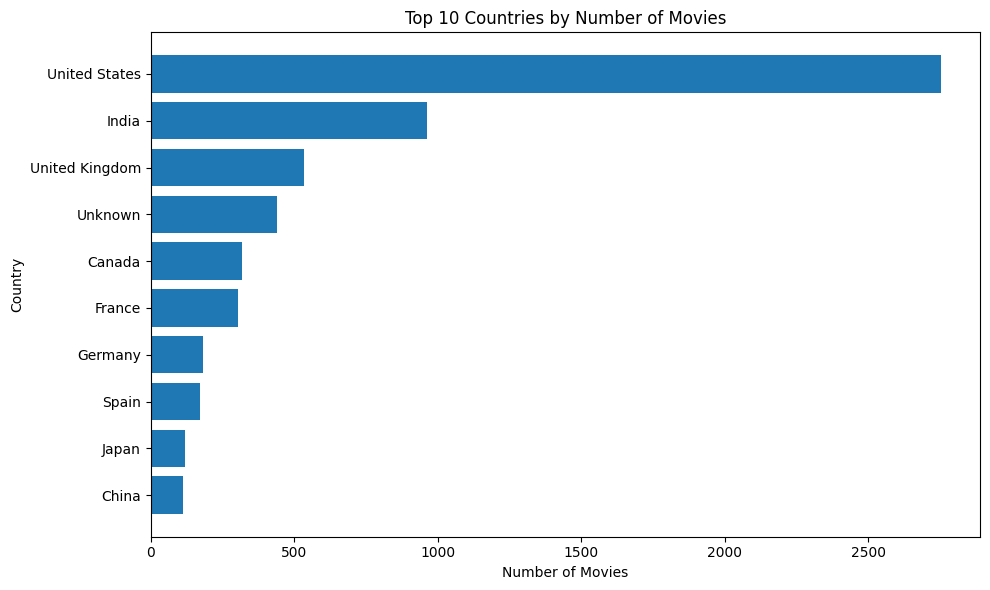

In [0]:
country_pd = top_movie_countries.toPandas()

plt.figure(figsize=(10, 6))

plt.barh(
    country_pd["country"],
    country_pd["total_titles"]
)

plt.title("Top 10 Countries by Number of Movies")
plt.xlabel("Number of Movies")
plt.ylabel("Country")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

### 7.2 Top 10 Genres

The visualization highlights the most common genres across the Netflix catalog.

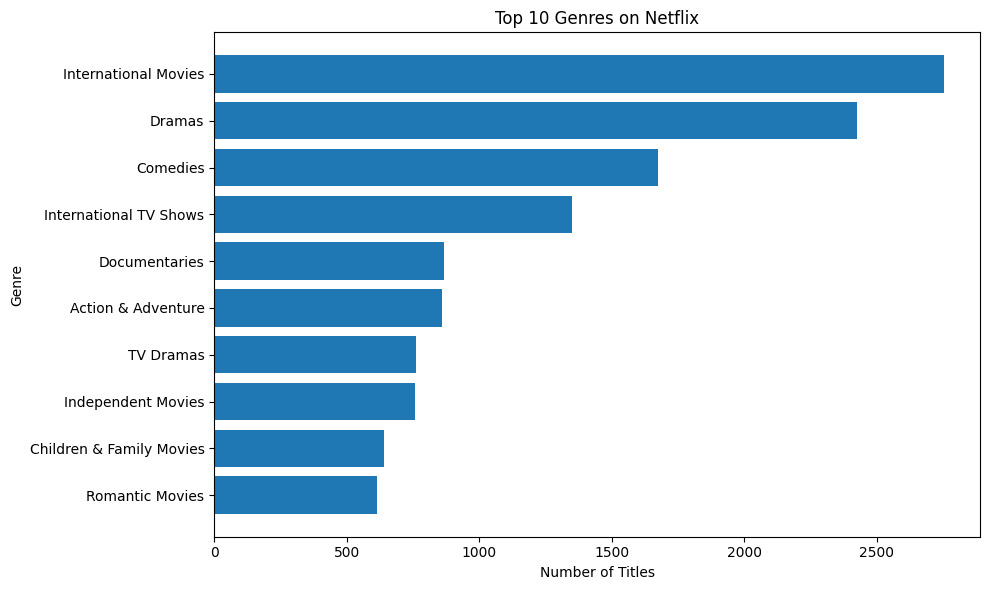

In [0]:
genre_pd = top_genres.toPandas()
plt.figure(figsize=(10, 6))

plt.barh(
    genre_pd["genre"],
    genre_pd["total_titles"]
)

plt.xlabel("Number of Titles")
plt.ylabel("Genre")
plt.title("Top 10 Genres on Netflix")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 7.3 Movies vs TV Shows Added by Year

The visualization shows how the number of Movies and TV Shows added to Netflix changed over time.

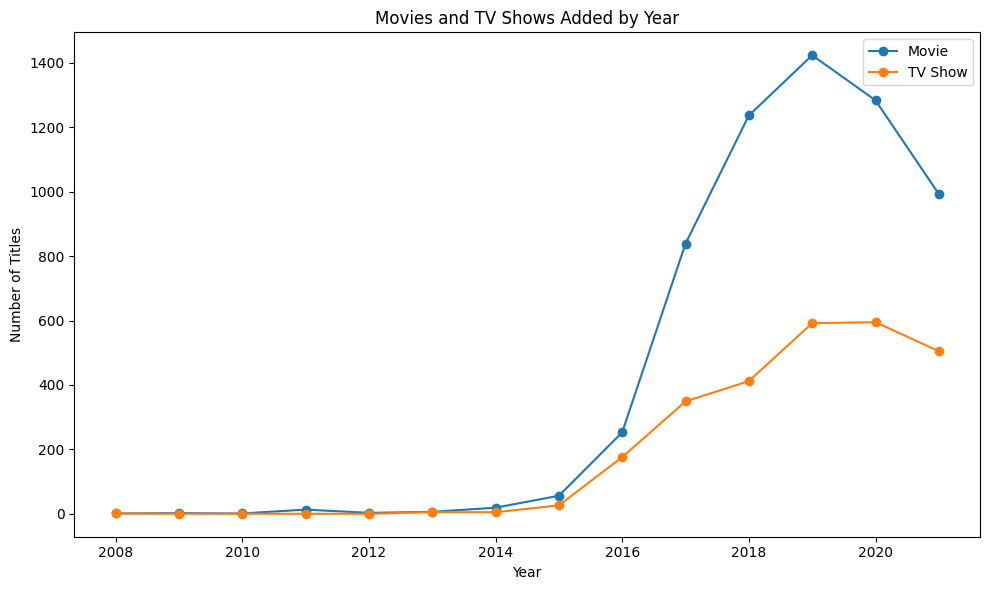

In [0]:
year_pd = year_pivot.toPandas()

plt.figure(figsize=(10, 6))

plt.plot(
    year_pd["added_year"],
    year_pd["Movie"],
    marker="o",
    label="Movie"
)

plt.plot(
    year_pd["added_year"],
    year_pd["TV Show"],
    marker="o",
    label="TV Show"
)

plt.title("Movies and TV Shows Added by Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")

plt.legend()
plt.tight_layout()
plt.show()

### 7.4 Most Common Ratings

The visualization highlights the most common content ratings across the Netflix catalog.

In [0]:
top_ratings = (
    gold_rating
    .groupBy("rating")
    .agg(
        spark_sum("total_titles").alias("total_titles")
    )
    .orderBy(col("total_titles").desc())
    .limit(10)
)

top_ratings.show(truncate=False)

+------+------------+
|rating|total_titles|
+------+------------+
|TV-MA |3207        |
|TV-14 |2160        |
|TV-PG |863         |
|R     |799         |
|PG-13 |490         |
|TV-Y7 |334         |
|TV-Y  |307         |
|PG    |287         |
|TV-G  |220         |
|NR    |80          |
+------+------------+



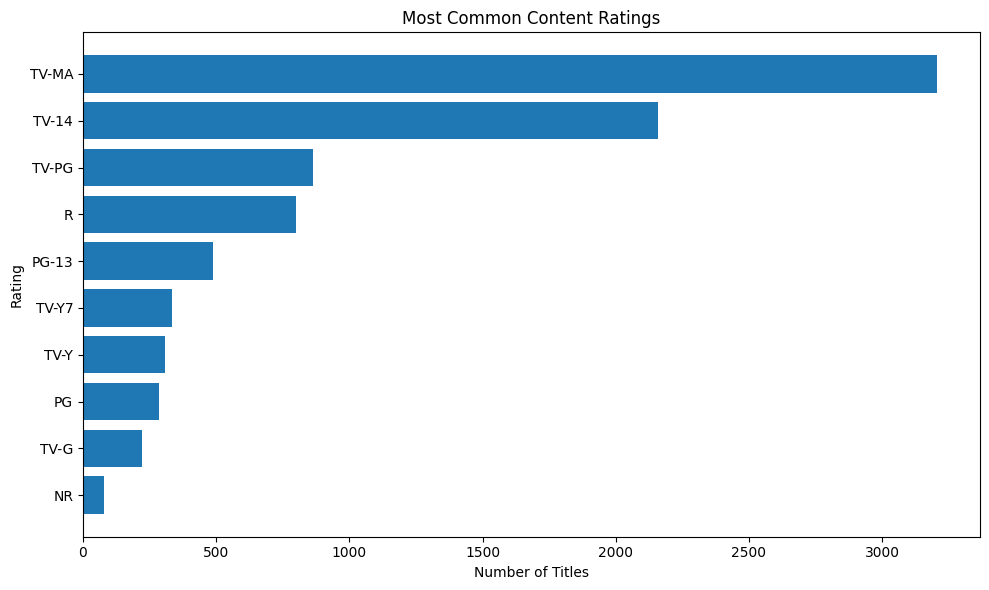

In [0]:
rating_pd = top_ratings.toPandas()

plt.figure(figsize=(10, 6))

plt.barh(
    rating_pd["rating"],
    rating_pd["total_titles"]
)

plt.title("Most Common Content Ratings")
plt.xlabel("Number of Titles")
plt.ylabel("Rating")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()


## 8. Persist Final Gold Layer

The validated Gold datasets are persisted as Delta tables so they can be reused for downstream analysis and reporting.

In [0]:
gold_country.printSchema()
gold_genre.printSchema()
gold_rating.printSchema()
gold_added_year.printSchema()
gold_duration.printSchema()

root
 |-- country: string (nullable = false)
 |-- type: string (nullable = true)
 |-- total_titles: long (nullable = false)

root
 |-- genre: string (nullable = false)
 |-- type: string (nullable = true)
 |-- total_titles: long (nullable = false)

root
 |-- rating: string (nullable = true)
 |-- type: string (nullable = true)
 |-- total_titles: long (nullable = false)

root
 |-- added_year: integer (nullable = true)
 |-- type: string (nullable = true)
 |-- total_titles: long (nullable = false)

root
 |-- duration_unit: string (nullable = true)
 |-- type: string (nullable = true)
 |-- total_titles: long (nullable = false)
 |-- avg_duration: double (nullable = true)
 |-- min_duration: integer (nullable = true)
 |-- max_duration: integer (nullable = true)



In [0]:
print("gold_country:", gold_country.count())
print("gold_genre:", gold_genre.count())
print("gold_rating:", gold_rating.count())
print("gold_added_year:", gold_added_year.count())
print("gold_duration:", gold_duration.count())

gold_country: 184
gold_genre: 42
gold_rating: 25
gold_added_year: 24
gold_duration: 2


In [0]:
gold_paths = {
    "gold_country": "/Volumes/workspace/default/netflix_vol/gold/gold_country",
    "gold_genre": "/Volumes/workspace/default/netflix_vol/gold/gold_genre",
    "gold_rating": "/Volumes/workspace/default/netflix_vol/gold/gold_rating",
    "gold_added_year": "/Volumes/workspace/default/netflix_vol/gold/gold_added_year",
    "gold_duration": "/Volumes/workspace/default/netflix_vol/gold/gold_duration"
}

In [0]:
gold_country.write.format("delta").mode("overwrite").option("overwriteSchema", "true").save(gold_paths["gold_country"])

gold_genre.write.format("delta").mode("overwrite").option("overwriteSchema", "true").save(gold_paths["gold_genre"])

gold_rating.write.format("delta").mode("overwrite").option("overwriteSchema", "true").save(gold_paths["gold_rating"])

gold_added_year.write.format("delta").mode("overwrite").option("overwriteSchema", "true").save(gold_paths["gold_added_year"])

gold_duration.write.format("delta").mode("overwrite").option("overwriteSchema", "true").save(gold_paths["gold_duration"])

## 9. Final Read-Back Validation

The persisted Gold Delta tables are read back from their storage paths to confirm that the final datasets were saved successfully and retain the expected structure and record counts.

In [0]:
gold_country_final = spark.read.format("delta").load(gold_paths["gold_country"])
gold_genre_final = spark.read.format("delta").load(gold_paths["gold_genre"])
gold_rating_final = spark.read.format("delta").load(gold_paths["gold_rating"])
gold_added_year_final = spark.read.format("delta").load(gold_paths["gold_added_year"])
gold_duration_final = spark.read.format("delta").load(gold_paths["gold_duration"])

In [0]:
print("gold_country:", gold_country_final.count())
print("gold_genre:", gold_genre_final.count())
print("gold_rating:", gold_rating_final.count())
print("gold_added_year:", gold_added_year_final.count())
print("gold_duration:", gold_duration_final.count())

gold_country: 184
gold_genre: 42
gold_rating: 25
gold_added_year: 24
gold_duration: 2


In [0]:
gold_country_final.printSchema()
gold_genre_final.printSchema()
gold_rating_final.printSchema()
gold_added_year_final.printSchema()
gold_duration_final.printSchema()

root
 |-- country: string (nullable = true)
 |-- type: string (nullable = true)
 |-- total_titles: long (nullable = true)

root
 |-- genre: string (nullable = true)
 |-- type: string (nullable = true)
 |-- total_titles: long (nullable = true)

root
 |-- rating: string (nullable = true)
 |-- type: string (nullable = true)
 |-- total_titles: long (nullable = true)

root
 |-- added_year: integer (nullable = true)
 |-- type: string (nullable = true)
 |-- total_titles: long (nullable = true)

root
 |-- duration_unit: string (nullable = true)
 |-- type: string (nullable = true)
 |-- total_titles: long (nullable = true)
 |-- avg_duration: double (nullable = true)
 |-- min_duration: integer (nullable = true)
 |-- max_duration: integer (nullable = true)



## 10. Key Findings & Conclusion

### Key Findings

- Movies make up the larger share of the Netflix catalog, with 6,131 Movies compared with 2,676 TV Shows.
- The United States has the highest number of Movies in the country-level analysis.
- International Movies, Dramas, and Comedies are among the most common genres in the catalog.
- The catalog contains a wide range of content ratings, with the most common ratings identified through the rating analysis.
- The number of Movies and TV Shows added to Netflix varies across years, showing changes in catalog growth over time.
- Movie durations are measured in minutes, while TV Show durations are measured in seasons, so their duration statistics were analyzed separately.

### Conclusion

This project demonstrates an end-to-end data engineering workflow using PySpark and Databricks. The Netflix dataset was ingested into the Bronze layer, cleaned and transformed in the Silver layer, and modeled into purpose-built analytical datasets in the Gold layer.

The pipeline includes data quality checks, handling of missing and inconsistent values, date and duration transformations, analytical aggregations, Delta Lake persistence, and visualizations. The final Gold datasets provide a structured foundation for analyzing Netflix content by country, genre, rating, year, and duration.